<a href="https://colab.research.google.com/github/devansh98185/CSET343/blob/main/Lab_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
'''Name: Sumit Parashar
    Enrollment Number: E23CSEU1080'''
!pip install kagglehub pandas numpy matplotlib seaborn scipy scikit-learn wfdb

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 3.7 MB/s eta 0:00:00


In [ ]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import os

path = kagglehub.dataset_download("jamaltariqcheema/pima-indians-diabetes-dataset")
csv_file = [f for f in os.listdir(path) if f.endswith('.csv')][0]
df = pd.read_csv(os.path.join(path, csv_file))

print("Dataset Shape:", df.shape)
display(df.head())

Using Colab cache for faster access to the 'pima-indians-diabetes-dataset' dataset.
Dataset Shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72.0,35,169.5,33.6,0.627,50,1
1,1,85,66.0,29,102.5,26.6,0.351,31,0
2,8,183,64.0,32,169.5,23.3,0.672,32,1
3,1,89,66.0,23,94.0,28.1,0.167,21,0
4,0,137,40.0,35,168.0,43.1,2.288,33,1


In [ ]:
cols_with_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df[cols_with_zeros] = df[cols_with_zeros].replace(0, np.nan)

df[cols_with_zeros] = df[cols_with_zeros].fillna(df[cols_with_zeros].median())

print("Missing values after cleaning:", df.isnull().sum().sum())
display(df.describe())

Missing values after cleaning: 0


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.677083,72.389323,29.089844,141.753906,32.434635,0.471876,33.240885,0.348958
std,3.369578,30.464161,12.106039,8.890820,89.100847,6.880498,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,102.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,28.000000,102.500000,32.050000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,169.500000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [ ]:
group_0 = df[df['Outcome'] == 0]['Glucose']
ggroup_1 = df[df['Outcome'] == 1]['Glucose']
t_stat, p_val = stats.ttest_ind(group_0, ggroup_1)
print(f"T-test: p-value = {p_val:.4f}")

df['AgeGroup'] = pd.cut(df['Age'], bins=[20, 30, 40, 50, 90], labels=['20s', '30s', '40s', '50+'])
anova_res = stats.f_oneway(*(df[df['AgeGroup'] == g]['BMI'] for g in df['AgeGroup'].unique()))
print(f"ANOVA: p-value = {anova_res.pvalue:.4f}")

df['HighPreg'] = df['Pregnancies'] > 5
contingency_table = pd.crosstab(df['HighPreg'], df['Outcome'])
chi2, p, _, _ = stats.chi2_contingency(contingency_table)
print(f"Chi-square: p-value = {p:.4f}")

T-test: p-value = 0.0000
ANOVA: p-value = 0.0010
Chi-square: p-value = 0.0000


In [ ]:
import re
import nltk
from nltk.tokenize import word_tokenize
nltk.download('punkt')

text_path = kagglehub.dataset_download("tboyle10/medicaltranscriptions")
text_df = pd.read_csv(os.path.join(text_path, 'mtsamples.csv'))

text_df = text_df.dropna(subset=['transcription'])
print(f"Loaded {len(text_df)} transcriptions.")
display(text_df[['medical_specialty', 'transcription']].head())

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


Using Colab cache for faster access to the 'medicaltranscriptions' dataset.
Loaded 4966 transcriptions.


,medical_specialty,transcription
0,Allergy / Immunology,"SUBJECTIVE:, This 23-year-old white female pr..."
1,Bariatrics,"PAST MEDICAL HISTORY:, He has difficulty climb..."
2,Bariatrics,"HISTORY OF PRESENT ILLNESS: , I have seen ABC ..."
3,Cardiovascular / Pulmonary,"2-D M-MODE: , ,1. Left atrial enlargement wit..."
4,Cardiovascular / Pulmonary,1. The left ventricular cavity size and wall ...


In [ ]:
def clean_medical_text(text):
    text = re.sub(r'\d{1,2}/\d{1,2}/\d{2,4}', '[DATE REDACTED]', text)
    text = re.sub(r'Age:?\s*\d+', 'Age: [REDACTED]', text, flags=re.I)
    text = text.lower()
    text = re.sub(r'[^a-z0-9\s\[\]]', '', text)
    return text

text_df['cleaned_transcription'] = text_df['transcription'].apply(clean_medical_text)

print("Original vs Cleaned:")
print(text_df['transcription'].iloc[0][:150])
print("---")
print(text_df['cleaned_transcription'].iloc[0][:150])

Original vs Cleaned:
SUBJECTIVE:,  This 23-year-old white female presents with complaint of allergies.  She used to have allergies when she lived in Seattle but she thinks
---
subjective  this 23yearold white female presents with complaint of allergies  she used to have allergies when she lived in seattle but she thinks they


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.tokenize import word_tokenize
import re

def clean_medical_text(text):
    text = re.sub(r'\d{1,2}/\d{1,2}/\d{2,4}', '[DATE REDACTED]', text)
    text = re.sub(r'Age:?\s*\d+', 'Age: [REDACTED]', text, flags=re.I)
    text = text.lower()
    text = re.sub(r'[^a-z0-9\s\[\]]', '', text)
    return text

text_df['cleaned_transcription'] = text_df['transcription'].apply(clean_medical_text)
text_df['tokens'] = text_df['cleaned_transcription'].apply(word_tokenize)

tfidf = TfidfVectorizer(max_features=1000, stop_words='english')
X_text = tfidf.fit_transform(text_df['cleaned_transcription'])

print("Shape of TF-IDF matrix:", X_text.shape)
print("Example tokens from first record:", text_df['tokens'].iloc[0][:10])

Shape of TF-IDF matrix: (4966, 1000)
Example tokens from first record: ['subjective', 'this', '23yearold', 'white', 'female', 'presents', 'with', 'complaint', 'of', 'allergies']


Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.


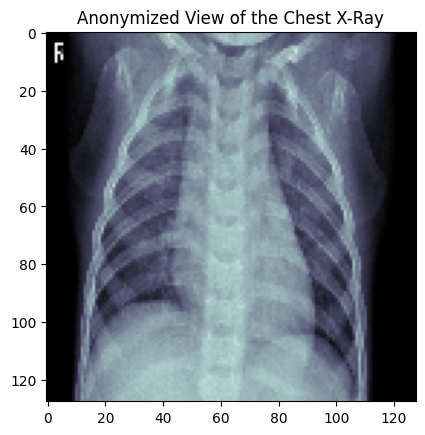

In [ ]:
import cv2
import glob

img_path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")
test_images = glob.glob(os.path.join(img_path, "chest_xray/test/NORMAL/*.jpeg"))

def preprocess_medical_image(path, target_size=(128, 128)):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

    img_resized = cv2.resize(img, target_size)
    img_normalized = img_resized / 255.0
    return img_normalized

sample_img = preprocess_medical_image(test_images[0])
plt.imshow(sample_img, cmap='bone')
plt.title("Anonymized View of the Chest X-Ray")
plt.show()

Generating record list for: 100
Generating list of all files for: 100
Finished downloading files


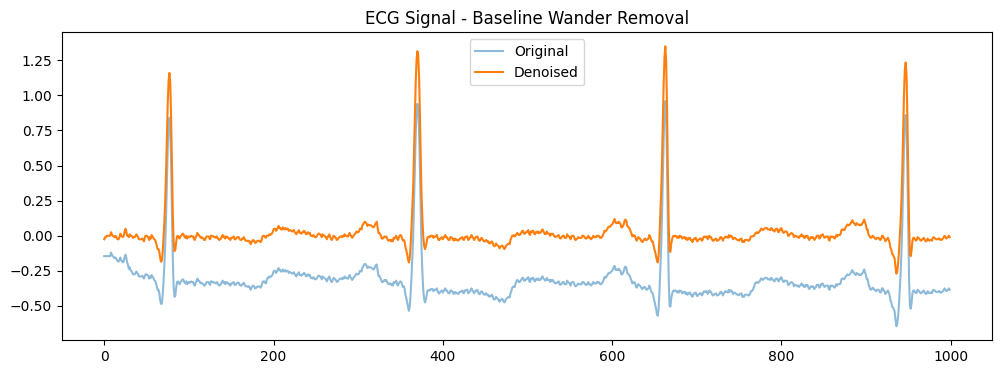

In [ ]:
import wfdb
from scipy.signal import medfilt

wfdb.dl_database('mitdb', dl_dir='mitdb_data', records=['100'])
record = wfdb.rdrecord('mitdb_data/100')
signal = record.p_signal[:, 0]

def denoise_signal(sig):
    b1 = medfilt(sig, 71)
    b2 = medfilt(b1, 215)
    return sig - b2

cleaned_signal = denoise_signal(signal)

window_size = 360
windowed_data = cleaned_signal[:window_size]

plt.figure(figsize=(12, 4))
plt.plot(signal[:1000], label='Original', alpha=0.5)
plt.plot(cleaned_signal[:1000], label='Denoised')
plt.title("ECG Signal - Baseline Wander Removal")
plt.legend()
plt.show()